<a href="https://colab.research.google.com/github/duryupin/ml_trading/blob/main/main_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install moexalgo -q
!pip install pandas-ta -q

In [ ]:
!pip install jupyter_contrib_nbextensions -q

In [ ]:
!pip install numpy==1.26.4

## Библиотеки

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from datetime import datetime, timedelta

import pandas_ta as ta

import pandas_datareader.data as web

import seaborn as sns

import moexalgo

import lightgbm as lgb

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.regression.rolling import RollingOLS
import statsmodels.api as sm

from scipy.stats import randint, uniform

import warnings

import requests

from bs4 import BeautifulSoup

import time

In [ ]:
warnings.filterwarnings("ignore")

# Graphics in SVG format are more sharp and legible
%config InlineBackend.figure_format = 'svg'

sns.set_theme(rc={'figure.figsize':(12, 6)})
#sns.set_palette("viridis")

pd.set_option('display.max_columns', None)

%matplotlib inline

# Новый раздел

In [ ]:
START_DATE = pd.to_datetime('2014-01-01')
END_DATE = datetime.now()
TICKER='CHMF'

In [ ]:
stock = moexalgo.Ticker(TICKER)
data_d = pd.DataFrame(stock.candles(
    start=START_DATE,
    end=END_DATE,
    period='1d'
            ))

In [ ]:
data_d.set_index('begin', inplace=True)

In [ ]:
data_d.head()

,open,close,high,low,value,volume,end
begin,,,,,,,
2014-01-06,246.05,242.30,247.50,242.00,6.822140e+08,1.402085e+10,2014-01-06 23:59:59
2014-01-08,243.00,239.55,243.00,239.50,4.980425e+08,1.034113e+10,2014-01-08 23:59:59
2014-01-09,239.60,240.60,242.00,238.70,8.381621e+08,1.742016e+10,2014-01-09 23:59:59
2014-01-10,240.15,242.30,242.90,239.00,7.712668e+08,1.598284e+10,2014-01-10 23:59:59
2014-01-13,242.05,244.60,246.45,241.25,1.213800e+09,2.485030e+10,2014-01-13 23:59:59


In [ ]:
monthly = data_d.resample('W').last()['close']

In [ ]:
monthly.head()

,close
begin,
2014-01-31,227.20
2014-02-28,210.65
2014-03-31,198.00
2014-04-30,193.25
2014-05-31,239.50


In [ ]:
outlier_cutoff = 0.01
data = pd.DataFrame()
lags = [1, 2, 3, 6, 9, 12]

In [ ]:
for lag in lags:
    data[f'return_{lag}m'] = (monthly.pct_change(lag)
    .pipe(lambda x: x.clip(lower=x.quantile(outlier_cutoff),
                            upper=x.quantile(1-outlier_cutoff)))
    .add(1)
    .pow(1/lag)
    .sub(1)
    )

In [ ]:
data = data.dropna()
data.head()

,return_1m,return_2m,return_3m,return_6m,return_9m,return_12m
begin,,,,,,
2015-01-31,0.028955,0.203478,0.179271,0.095884,0.066411,0.035347
2015-02-28,-0.013635,0.007435,0.133437,0.097306,0.039700,0.040702
2015-03-31,-0.117647,-0.067089,-0.036114,0.078910,0.042933,0.035233
2015-04-30,0.091667,-0.018554,-0.016917,0.085985,0.056914,0.044939
2015-05-31,0.225191,0.156503,0.056766,0.094430,0.080397,0.043941


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 124 entries, 2015-01-31 to 2025-04-30
Freq: ME
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   return_1m   124 non-null    float64
 1   return_2m   124 non-null    float64
 2   return_3m   124 non-null    float64
 3   return_6m   124 non-null    float64
 4   return_9m   124 non-null    float64
 5   return_12m  124 non-null    float64
dtypes: float64(6)
memory usage: 6.8 KB


In [ ]:
for lag in [2,3,6,9,12]:
  data[f'momentum_{lag}'] = data[f'return_{lag}m'].sub(data.return_1m)

In [ ]:
data[f'momentum_3_12'] = data[f'return_12m'].sub(data.return_3m)

In [ ]:
data[f'momentum_3_9'] = data[f'return_9m'].sub(data.return_3m)

In [ ]:
data.head()

,return_1m,return_2m,return_3m,return_6m,return_9m,return_12m,momentum_2,momentum_3,momentum_6,momentum_9,momentum_12,momentum_3_12,momentum_3_9
begin,,,,,,,,,,,,,
2015-01-31,0.028955,0.203478,0.179271,0.095884,0.066411,0.035347,0.174523,0.150315,0.066929,0.037456,0.006392,-0.143923,-0.112860
2015-02-28,-0.013635,0.007435,0.133437,0.097306,0.039700,0.040702,0.021070,0.147072,0.110941,0.053335,0.054337,-0.092735,-0.093737
2015-03-31,-0.117647,-0.067089,-0.036114,0.078910,0.042933,0.035233,0.050558,0.081533,0.196557,0.160581,0.152880,0.071347,0.079048
2015-04-30,0.091667,-0.018554,-0.016917,0.085985,0.056914,0.044939,-0.110221,-0.108584,-0.005682,-0.034752,-0.046728,0.061857,0.073832
2015-05-31,0.225191,0.156503,0.056766,0.094430,0.080397,0.043941,-0.068687,-0.168425,-0.130761,-0.144794,-0.181250,-0.012825,0.023631


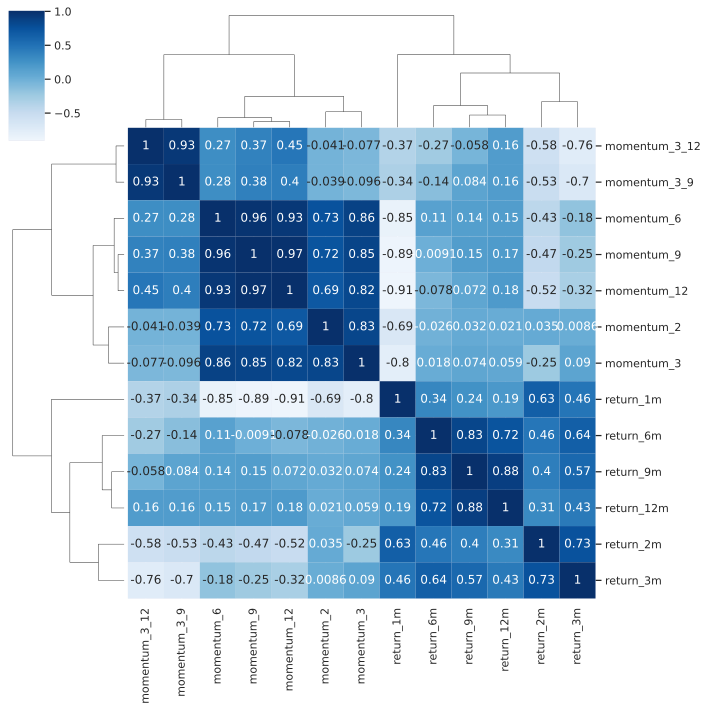

In [ ]:
sns.clustermap(data.corr('spearman'), annot=True, center=0, cmap='Blues');

In [ ]:
dates = data.index.get_level_values('begin')
data['year'] = dates.year
data['month'] = dates.month

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 124 entries, 2015-01-31 to 2025-04-30
Freq: ME
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   return_1m      124 non-null    float64
 1   return_2m      124 non-null    float64
 2   return_3m      124 non-null    float64
 3   return_6m      124 non-null    float64
 4   return_9m      124 non-null    float64
 5   return_12m     124 non-null    float64
 6   momentum_2     124 non-null    float64
 7   momentum_3     124 non-null    float64
 8   momentum_6     124 non-null    float64
 9   momentum_9     124 non-null    float64
 10  momentum_12    124 non-null    float64
 11  momentum_3_12  124 non-null    float64
 12  momentum_3_9   124 non-null    float64
 13  year           124 non-null    int32  
 14  month          124 non-null    int32  
dtypes: float64(13), int32(2)
memory usage: 14.5 KB


In [ ]:
for t in range(1, 7):
  data[f'return_1m_t-{t}'] = data.return_1m.shift(t)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 124 entries, 2015-01-31 to 2025-04-30
Freq: ME
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   return_1m      124 non-null    float64
 1   return_2m      124 non-null    float64
 2   return_3m      124 non-null    float64
 3   return_6m      124 non-null    float64
 4   return_9m      124 non-null    float64
 5   return_12m     124 non-null    float64
 6   momentum_2     124 non-null    float64
 7   momentum_3     124 non-null    float64
 8   momentum_6     124 non-null    float64
 9   momentum_9     124 non-null    float64
 10  momentum_12    124 non-null    float64
 11  momentum_3_12  124 non-null    float64
 12  momentum_3_9   124 non-null    float64
 13  year           124 non-null    int32  
 14  month          124 non-null    int32  
 15  return_1m_t-1  123 non-null    float64
 16  return_1m_t-2  122 non-null    float64
 17  return_1m_t-3  121 non-nul

In [ ]:
data.ta.indicators()

Pandas TA - Technical Analysis Indicators - v0.3.14b0
Total Indicators & Utilities: 205
Abbreviations:
    aberration, above, above_value, accbands, ad, adosc, adx, alma, amat, ao, aobv, apo, aroon, atr, bbands, below, below_value, bias, bop, brar, cci, cdl_pattern, cdl_z, cfo, cg, chop, cksp, cmf, cmo, coppock, cross, cross_value, cti, decay, decreasing, dema, dm, donchian, dpo, ebsw, efi, ema, entropy, eom, er, eri, fisher, fwma, ha, hilo, hl2, hlc3, hma, hwc, hwma, ichimoku, increasing, inertia, jma, kama, kc, kdj, kst, kurtosis, kvo, linreg, log_return, long_run, macd, mad, massi, mcgd, median, mfi, midpoint, midprice, mom, natr, nvi, obv, ohlc4, pdist, percent_return, pgo, ppo, psar, psl, pvi, pvo, pvol, pvr, pvt, pwma, qqe, qstick, quantile, rma, roc, rsi, rsx, rvgi, rvi, short_run, sinwma, skew, slope, sma, smi, squeeze, squeeze_pro, ssf, stc, stdev, stoch, stochrsi, supertrend, swma, t3, td_seq, tema, thermo, tos_stdevall, trima, trix, true_range, tsi, tsignals, ttm_trend, ui, 

In [ ]:
help(ta.bbands)

In [ ]:
macd = data_d.ta.macd(fast=12, slow=21, signal=9).tail(20)

In [ ]:
macd.head()

,MACD_12_21_9,MACDh_12_21_9,MACDs_12_21_9
begin,,,
2025-03-14,0.480426,-0.374339,0.854764
2025-03-15,0.449691,-0.324058,0.773750
2025-03-16,0.499690,-0.219248,0.718938
2025-03-17,0.550672,-0.134612,0.685285
2025-03-18,0.426733,-0.206841,0.633574


In [ ]:
CommonStrategy = ta.CommonStrategy
print("name =", CommonStrategy.name)
print("description =", CommonStrategy.description)
print("created =", CommonStrategy.created)
print("ta =", CommonStrategy.ta)

name = Common Price and Volume SMAs
description = Common Price SMAs: 10, 20, 50, 200 and Volume SMA: 20.
created = Friday April 4, 2025, NYSE: 8:36:49, Local: 12:36:49 UTC, Day 94/365 (26.00%)
ta = [{'kind': 'sma', 'length': 10}, {'kind': 'sma', 'length': 20}, {'kind': 'sma', 'length': 50}, {'kind': 'sma', 'length': 200}, {'kind': 'sma', 'close': 'volume', 'length': 20, 'prefix': 'VOL'}]


In [ ]:
m_bband = ta.bbands(monthly)

In [ ]:
m_bband.tail()

,BBL_5_2.0,BBM_5_2.0,BBU_5_2.0,BBB_5_2.0,BBP_5_2.0
begin,,,,,
2024-12-31,64.552295,81.058,97.563705,40.725666,0.468859
2025-01-31,66.021763,79.540,93.058237,33.991040,0.660894
2025-02-28,64.979415,80.074,95.168585,37.701589,0.885105
2025-03-31,67.102669,81.416,95.729331,35.160979,0.519003
2025-04-30,71.567788,82.510,93.452212,26.523359,0.155463


In [ ]:
m_rsi = ta.rsi(monthly)

In [ ]:
m_rsi.tail()

,RSI_14
begin,
2024-12-31,37.733469
2025-01-31,39.736121
2025-02-28,43.682871
2025-03-31,40.151249
2025-04-30,37.789994


In [ ]:
data_plot = pd.DataFrame({
    'bb_up': m_bband['BBU_5_2.0'],
    'bb_mid': m_bband['BBM_5_2.0'],
    'bb_low': m_bband['BBL_5_2.0'],
    'rsi': m_rsi})

In [ ]:
data_plot.tail()

,bb_up,bb_mid,bb_low,rsi
begin,,,,
2024-12-31,97.563705,81.058,64.552295,37.733469
2025-01-31,93.058237,79.540,66.021763,39.736121
2025-02-28,95.168585,80.074,64.979415,43.682871
2025-03-31,95.729331,81.416,67.102669,40.151249
2025-04-30,93.452212,82.510,71.567788,37.789994


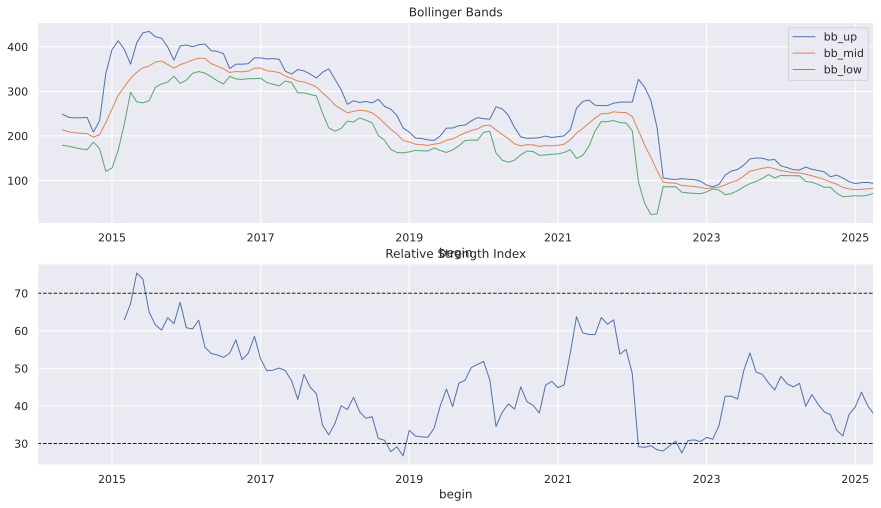

In [ ]:
fig, axes= plt.subplots(nrows=2, figsize=(15, 8))
data_plot.drop('rsi', axis=1).plot(ax=axes[0], lw=1, title='Bollinger Bands')
data_plot['rsi'].plot(ax=axes[1], lw=1, title='Relative Strength Index')
axes[1].axhline(70, lw=1, ls='--', c='k')
axes[1].axhline(30, lw=1, ls='--', c='k')
plt.show()

data_w = pd.DataFrame(stock.candles(
    start=START_DATE,
    end=END_DATE,
    period='1w'
            ))

In [ ]:
data_d.head()

In [ ]:
data_w.head()

data['end'] = pd.to_datetime(data['end'].dt.date)

In [ ]:
data_d.set_index('begin', inplace=True)

In [ ]:
data_w.set_index('begin', inplace=True)

data.index = data.index.date

In [ ]:
data_d.head(10)

In [ ]:
data_w.head(10)

In [ ]:
result = data_d.merge(data_w, left_index=True, right_index=True, suffixes=('', '_weekly'), how='left')

In [ ]:
result.head(10)

In [ ]:
for column in ['open_weekly', 'high_weekly', 'low_weekly', 'close_weekly', 'volume_weekly']:
    result[column] = result[column].fillna(result[column].groupby(pd.Grouper(freq='W')).transform('first'))

In [ ]:
result.head(10)

In [ ]:
result['vwap'] = (result['close'] * result['volume']).cumsum() / result['volume'].cumsum()
result['vwap_weekly'] = (result['close_weekly'] * result['volume_weekly']).cumsum() / result['volume_weekly'].cumsum()

In [ ]:
result.head()

In [ ]:
def price_volume(df, price='vwap', vol='volume', suptitle='title', fname=None):

    fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(15,8))
    axes[0].plot(df.index, df[price])
    axes[1].bar(df.index, df[vol], width=1/(4*len(df.index)), color='red')

    # formatting
    #xfmt = mpl.dates.DateFormatter('%H:%M')
    #axes[1].xaxis.set_major_locator(mpl.dates.HourLocator(interval=3))
    #axes[1].xaxis.set_major_formatter(MaxNLocator(nbins=10))
    #axes[1].get_xaxis().set_tick_params(which='major', pad=25)
    axes[0].set_title('Price', fontsize=14)
    axes[1].set_title('Volume', fontsize=14)
    fig.autofmt_xdate()
    fig.suptitle(suptitle)
    fig.tight_layout()
    plt.subplots_adjust(top=0.9);

In [ ]:
price_volume(result)

## Парсинг

In [ ]:
url = 'https://smart-lab.ru/q/VTBR/f/y/RSBU/'

# Заголовки, чтобы замаскироваться под браузер
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.36"
}

# Скачиваем HTML страницы при помощи requests
response = requests.get(url, headers=headers)

soup = BeautifulSoup(response.text, 'html.parser')

In [ ]:
table = soup.find('table', class_='financials')

In [ ]:
data = {
    'year': ['2019', '2020', '2021', '2022', '2023'],
    'net_income': [],
    'shares': [],
    'net_intrst_incm': [],
    'p_e': [],
    'p_b': []
}

In [ ]:
def find_row_data(field_name):
    row = table.find('tr', attrs={'field': field_name})
    if row:
        return [td.get_text(strip=True) for td in row.find_all('td')[1:8]]
    return [None]*5

In [ ]:
data['net_income'] = find_row_data('net_income')
data['shares'] = find_row_data('number_of_shares')
data['net_intrst_incm'] = find_row_data('net_interest_income')
data['p_e'] = find_row_data('p_e')
data['p_b'] = find_row_data('p_b')

In [ ]:
data

In [ ]:
df_fundament = pd.DataFrame(data)

In [ ]:
df_fundament

In [ ]:
numeric_columns = ['net_income', 'shares', 'net_intrst_incm', 'p_e', 'p_b']
for col in numeric_columns:
  df_fundament[col] = pd.to_numeric(df_fundament[col].str.replace(' ', '').str.replace(',', '.'), errors='coerce')

In [ ]:
df_fundament

In [ ]:
weekly = data_d.resample('1W-FRI').agg({
            'open': 'first',
            'high': 'max',
            'low': 'min',
            'close': 'last',
            'volume': 'sum'})

In [ ]:
weekly.head()

In [ ]:
weekly_expanded = weekly.reindex(pd.date_range(start=weekly.index.min(), end=weekly.index.max(), freq='D'))

In [ ]:
weekly_expanded.head(20)

In [ ]:
weekly_expanded.fillna(method='ffill', inplace=True)

In [ ]:
# Объединение с исходными данными
data = data.merge(weekly_expanded[['open', 'high', 'low', 'close', 'volume']],
                    left_index=True, right_index=True, suffixes=('', '_weekly'))

In [ ]:
data.head(15)